# Assignment: Building and Analyzing Binary Classification Systems

## KUSHAL BHATT (a1951782)

---
**Course:** Machine Learning  
**Due Date:** 1st June 2026  
**Dataset:** MNIST Subset-Digits 1 and 7  
---


# Task 1: Data Exploration and Analysis

In this task we look at the training data closely,how many samples we have, what the images look like, any class imbalance, pixel stats, and what preprocessing we need before building a model.


In [3]:
# bring in all the stuff we need
# numpy for numbers, matplotlib for plots
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

data = np.load('mnist_1_7_subsets.npz')

# lets see what keys are inside the file first
print("Keys inside the file:", list(data.keys()))

Keys inside the file: ['train_data', 'train_targets', 'test_data', 'test_targets']


## Step 1.1 (Load and Inspect the Data)

In [4]:
# pull out each part using the keys we just found
X_train = data['train_data']      # training images
y_train = data['train_targets']   # training labels
X_test  = data['test_data']       # test images 
y_test  = data['test_targets']    # test labels

# basic shape check(how many samples and what size are the images)
print("BASIC DATA INSPECTION")
print(f"Training images shape  : {X_train.shape}")
print(f"Training labels shape  : {y_train.shape}")
print(f"Test images shape      : {X_test.shape}")
print(f"Test labels shape      : {y_test.shape}")

# checking what pixel values look like-should be 0 to 255
print(f"\nPixel value min  : {X_train.min()}")
print(f"Pixel value max  : {X_train.max()}")

# checking what digit classes we have
print(f"\nUnique classes in training : {np.unique(y_train)}")
print(f"Unique classes in test     : {np.unique(y_test)}")

BASIC DATA INSPECTION
Training images shape  : (100, 28, 28)
Training labels shape  : (100,)
Test images shape      : (1000, 28, 28)
Test labels shape      : (1000,)

Pixel value min  : 0
Pixel value max  : 255

Unique classes in training : [1 7]
Unique classes in test     : [1 7]


## Step 1.2 (Class Distribution & Key Statistics)

In [5]:
# counting how many 1s and 7s we got in training
count_1 = np.sum(y_train == 1)
count_7 = np.sum(y_train == 7)

print("CLASS DISTRIBUTION")
print(f"Digit 1 count : {count_1}")
print(f"Digit 7 count : {count_7}")
print(f"Total samples : {len(y_train)}")
print(f"Class balance ratio (1s vs 7s) : {count_1/count_7:.2f}")

# split images by class so we can look at each digit separately
imgs_1 = X_train[y_train == 1]
imgs_7 = X_train[y_train == 7]

print("\nPIXEL INTENSITY STATS")
print(f"Digit 1 - mean pixel intensity : {imgs_1.mean():.4f}")
print(f"Digit 7 - mean pixel intensity : {imgs_7.mean():.4f}")
print(f"Digit 1 - std pixel intensity  : {imgs_1.std():.4f}")
print(f"Digit 7 - std pixel intensity  : {imgs_7.std():.4f}")

# sparsity means how many pixels are white/empty background
# higher sparsity means the digit takes up less space in the image
sparsity_1 = (imgs_1 == 0).sum() / imgs_1.size * 100
sparsity_7 = (imgs_7 == 0).sum() / imgs_7.size * 100

print("\nPIXEL SPARSITY (percentage of zero/white pixels)")
print(f"Digit 1 - sparsity : {sparsity_1:.2f}%")
print(f"Digit 7 - sparsity : {sparsity_7:.2f}%")

# non zero pixels means actual ink on the page
# tells us how thick or spread out each digit is
avg_nonzero_1 = np.count_nonzero(imgs_1.reshape(len(imgs_1), -1), axis=1).mean()
avg_nonzero_7 = np.count_nonzero(imgs_7.reshape(len(imgs_7), -1), axis=1).mean()

print("\nAVERAGE INK PIXELS PER IMAGE")
print(f"Digit 1 - avg ink pixels : {avg_nonzero_1:.2f}")
print(f"Digit 7 - avg ink pixels : {avg_nonzero_7:.2f}")

CLASS DISTRIBUTION
Digit 1 count : 50
Digit 7 count : 50
Total samples : 100
Class balance ratio (1s vs 7s) : 1.00

PIXEL INTENSITY STATS
Digit 1 - mean pixel intensity : 20.1823
Digit 7 - mean pixel intensity : 29.5250
Digit 1 - std pixel intensity  : 63.7546
Digit 7 - std pixel intensity  : 74.8758

PIXEL SPARSITY (percentage of zero/white pixels)
Digit 1 - sparsity : 88.73%
Digit 7 - sparsity : 83.24%

AVERAGE INK PIXELS PER IMAGE
Digit 1 - avg ink pixels : 88.32
Digit 7 - avg ink pixels : 131.40


## Step 1.3 (Statistical Analysis & Insights)

**Class Distribution:**
So we got exactly 50 images for digit 1 and 50 for digit 7. That is perfect balance between the two classes. This matter a lot for classification because when classes are equal we can use accuracy as main metric without worrying that model just predict one class all the time to get high score.

**Mean Pixel Intensity:**
Digit 7 got higher mean intensity (29.53) than digit 1 (20.18). This make sense because 7 has two strokes,one horizontal on top and one diagonal going down,so more pixels are dark. Digit 1 is just thin vertical line so less dark pixels. This difference in brightness between two digits is good sign that classifier can tell them apart just from pixel values.

**Standard Deviation of Pixel Intensity:**
Digit 7 has higher std (74.88) compare to digit 1 (63.75). Basically digit 7 is written in more different ways by different people,some put crossbar some dont, some write diagonal steep some write it flat. Digit 1 is more consistent across all samples because its just a line. Lower variation in digit 1 mean model can learn cleaner pattern for that class.

**Pixel Sparsity:**
Digit 1 images are 88.73% empty and digit 7 images are 83.24% empty. So digit 7 take up more space on the image. The gap of about 5.5% might not sound big but across 784 pixels that is meaningful difference. This confirm again that these two digits look quite different in terms of how much of the image they fill up.

**Average Ink Pixels:**
Digit 7 use 131.40 ink pixels on average while digit 1 only use 88.32. That is almost 50% more ink for digit 7. This big gap come from the extra strokes in digit 7. For any model working in pixel space this difference in ink coverage should make it pretty easy to draw a boundary between the two classes.

## Step 1.4 (Visualizations)
### Visualization 1: Sample Images from Each Class

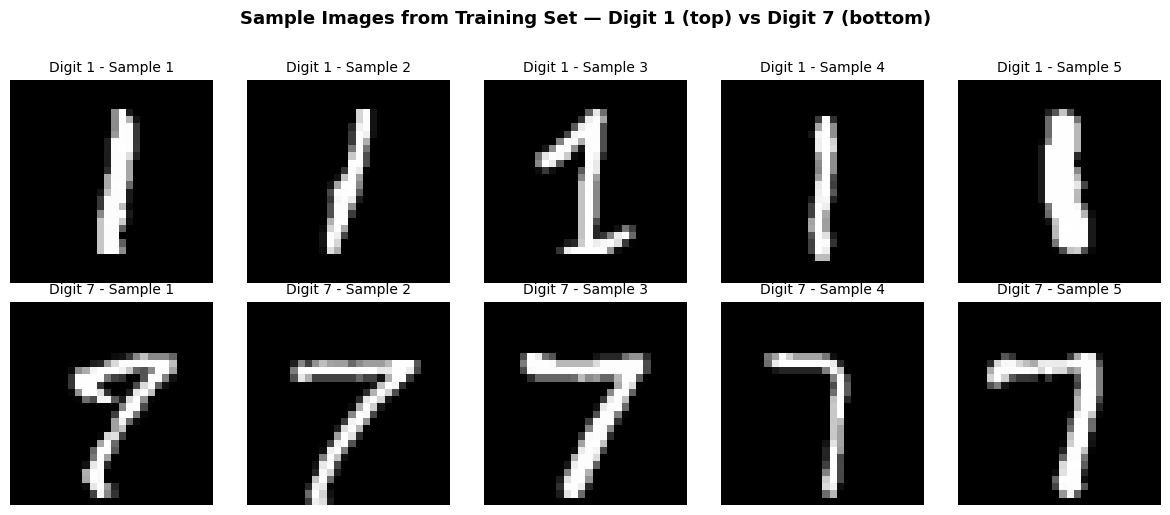

plot saved


In [6]:
# showing 5 samples from each class side by side
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# top row is digit 1, bottom row is digit 7
for i in range(5):
    # grab 5 random images for digit 1
    axes[0, i].imshow(imgs_1[i], cmap='gray')
    axes[0, i].set_title(f'Digit 1 - Sample {i+1}', fontsize=10)
    axes[0, i].axis('off')

for i in range(5):
    # grab 5 random images for digit 7
    axes[1, i].imshow(imgs_7[i], cmap='gray')
    axes[1, i].set_title(f'Digit 7 - Sample {i+1}', fontsize=10)
    axes[1, i].axis('off')

fig.suptitle('Sample Images from Training Set — Digit 1 (top) vs Digit 7 (bottom)', 
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('viz1_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

**Interpretation:** Just by looking at these samples we can already see these two digits are very different from each other. Digit 1 is basically just a thin line, sometimes straight sometimes a bit tilted. Digit 7 got two strokes,one going across the top and one going diagonal down. Because they look so different in shape a classifier should not have too much trouble telling them apart even just from raw pixel values.

### Visualization 2: Class Distribution

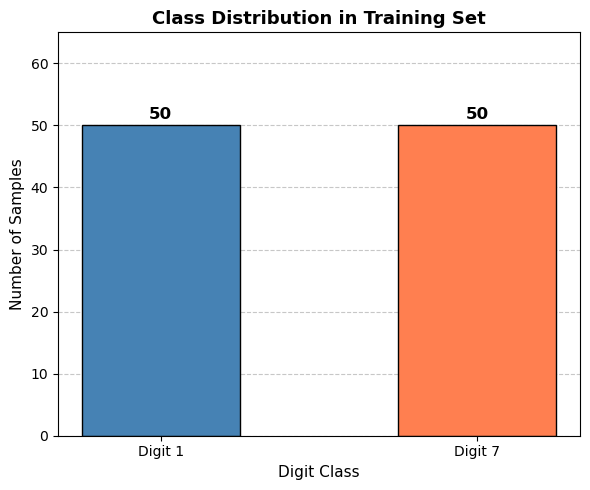

plot saved


In [7]:
# bar chart to show how many samples we have per class
# we already know its 50/50 but good to show it visually
fig, ax = plt.subplots(figsize=(6, 5))

classes = ['Digit 1', 'Digit 7']
counts  = [count_1, count_7]
colors  = ['steelblue', 'coral']

bars = ax.bar(classes, counts, color=colors, width=0.5, edgecolor='black')

# put the number on top of each bar so its easy to read
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.5, 
            str(count), 
            ha='center', va='bottom', 
            fontsize=12, fontweight='bold')

ax.set_title('Class Distribution in Training Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Digit Class', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_ylim(0, 65)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

**Interpretation:** Both classes got exactly 50 samples so no imbalance issue here. This is good because it mean we dont need to do anything special like oversample one class or use class weights. It also mean accuracy is fair metric to use-if model just guessed same class every time it would only get 50% so any score above that is actually meaningful.

### Visualization 3: Mean Image per Class

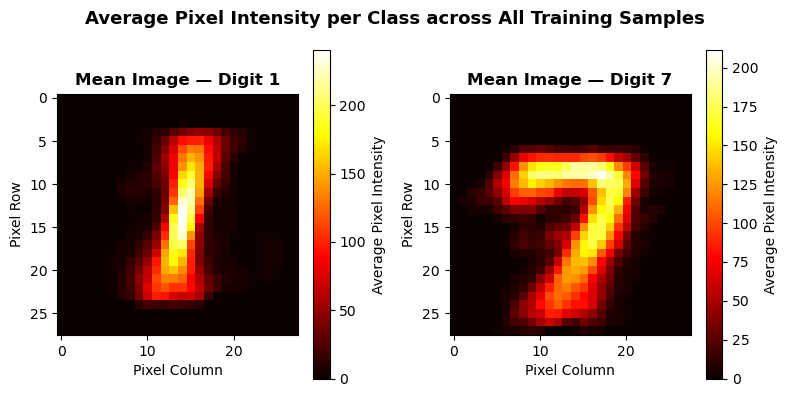

plot saved


In [8]:
# mean image is just the average of all 50 images for each digit
# this shows us the "typical" look of each digit in our dataset
mean_img_1 = imgs_1.mean(axis=0)
mean_img_7 = imgs_7.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

im1 = axes[0].imshow(mean_img_1, cmap='hot')
axes[0].set_title('Mean Image — Digit 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pixel Column', fontsize=10)
axes[0].set_ylabel('Pixel Row', fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Average Pixel Intensity')

im2 = axes[1].imshow(mean_img_7, cmap='hot')
axes[1].set_title('Mean Image — Digit 7', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pixel Column', fontsize=10)
axes[1].set_ylabel('Pixel Row', fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Average Pixel Intensity')

fig.suptitle('Average Pixel Intensity per Class across All Training Samples', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('viz3_mean_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

**Interpretation:** Mean image is basically what you get if you stack all 50 images on top of each other and average them out. For digit 1 you can see bright region in middle going vertical-that is where most people put their stroke. For digit 7 you can see bright horizontal bit at top and bright diagonal going down. The two mean images look nothing like each other which is good-it mean the two digits sit in completely different parts of the pixel space and classifier should be able to learn that difference pretty easily.

### Visualization 4: Pixel Variance Heatmap

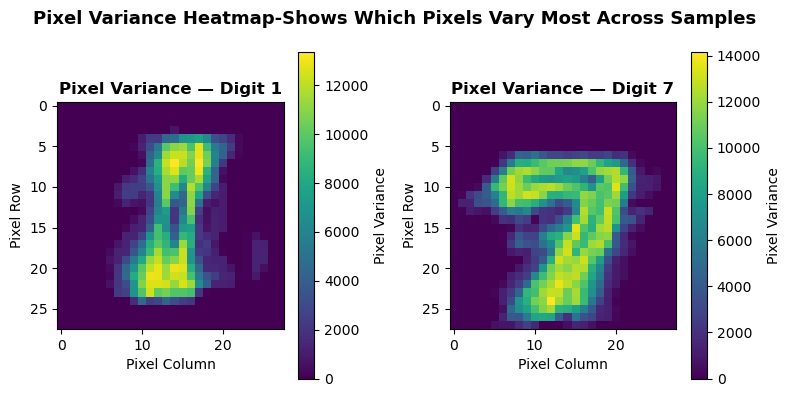

plot saved


In [9]:
# variance heatmap shows which pixels change a lot across different samples
# high variance pixels are the ones that differ most between people's handwriting
# low variance pixels are mostly background or very consistent strokes
var_img_1 = imgs_1.var(axis=0)
var_img_7 = imgs_7.var(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

im1 = axes[0].imshow(var_img_1, cmap='viridis')
axes[0].set_title('Pixel Variance — Digit 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pixel Column', fontsize=10)
axes[0].set_ylabel('Pixel Row', fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Pixel Variance')

im2 = axes[1].imshow(var_img_7, cmap='viridis')
axes[1].set_title('Pixel Variance — Digit 7', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pixel Column', fontsize=10)
axes[1].set_ylabel('Pixel Row', fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Pixel Variance')

fig.suptitle('Pixel Variance Heatmap-Shows Which Pixels Vary Most Across Samples',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('viz4_variance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

**Interpretation:** Variance heatmap show where pixels change most across different samples of same digit. For digit 1 the high variance is bunched up along where the vertical stroke goes,people write it in slightly different spots or angles. For digit 7 the high variance is more spread out because people write it in more different ways,some put crossbar some dont, angles vary etc. The important thing here is that the high variance areas of digit 1 and digit 7 are in very different parts of the image so even the most inconsistent pixels of each class dont really overlap with the other class. This make the two digits even easier to separate.

## Step 1.5 (Data Preprocessing)

In [10]:
# STEP 1: normalize pixel values from 0-255 down to 0-1
# reason: pixel values go up to 255 which is quite large number
# if we dont scale them down the model training can be slow and unstable
# dividing by 255 puts everything between 0 and 1 which is much better for most ML models
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

# STEP 2: flatten each image from 28x28 grid into single row of 784 numbers
# reason: sklearn models like SVM expect each sample to be a 1D array
# so we reshape (100, 28, 28) into (100, 784)
X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_test_flat  = X_test_norm.reshape(len(X_test_norm), -1)

# quick check to make sure shapes are correct after preprocessing
print("Shape after flattening")
print(f"X_train_flat : {X_train_flat.shape}")
print(f"X_test_flat  : {X_test_flat.shape}")

# confirm pixel range is now 0 to 1
print(f"\nPixel value min after normalisation : {X_train_flat.min()}")
print(f"Pixel value max after normalisation : {X_train_flat.max()}")

Shape after flattening
X_train_flat : (100, 784)
X_test_flat  : (1000, 784)

Pixel value min after normalisation : 0.0
Pixel value max after normalisation : 1.0


## Step 1.6 (Summary of Findings)

**Dataset Overview:**
We got 100 training images-50 are digit 1 and 50 are digit 7. Test set got 1000 images which we not touching until task 4. Each image is 28x28 pixels in grayscale, pixel values were from 0 to 255 before we normalised them.

**What we found from the stats:**
Both classes got exactly 50 samples each so no imbalance problem here, this mean accuracy is fair to use as evaluation metric. Digit 7 got higher average pixel intensity (29.53) than digit 1 (20.18) which make sense because 7 got more strokes. Digit 1 got lower std (63.75) compare to digit 7 (74.88) meaning people write 1 more same way each time but 7 got more variation,some people put crossbar some dont. Digit 7 also use way more ink pixels (131.40) compare to digit 1 (88.32), thats almost 50% more ink which is big difference.

**What the visualisations showed:**
From sample images we can see digit 1 is thin vertical line and digit 7 got horizontal stroke on top plus diagonal going down,very different shapes. Mean images make this even more clear, you can see exactly where each digit sit in the image. Variance heatmap show that digit 7 got more spread out high variance areas because people write it differently, digit 1 variance is more concentrated along the vertical stroke.

**Preprocessing decisions:**
We did two things. First we divide all pixel values by 255 to bring them from 0-255 range down to 0-1. Big pixel values can slow down training and cause instability so scaling them down is important. Second we flatten each 28x28 image into 1D array of 784 values because sklearn models need flat feature vector not 2D grid.

**Link to classification task:**
Digit 1 and digit 7 look very different from each other-one is thin vertical line and other is multi stroke shape. This big visual difference plus the gap in ink coverage and intensity suggest these two classes should be easy to separate in pixel space. Even with only 100 training samples a linear classifier should find good boundary between them.

# Task 2: (Build a Classification System)

In this task we pick one classifier, explain why we chose it based on what we found in task 1, train it on the training data only, and then evaluate it using multiple metrics.

## Step 2.1 (Model Choice & Justification)

We going with **Linear SVM (Support Vector Machine with linear kernel)**.

**Why we picked this:**
So in task 1 we found that we only got 100 training images but each image got 784 pixel features. That is way more features than samples. Linear SVM is actually really good in this situation,it dont get confused by high dimensions like some other models do.

Also from task 1 the mean images showed digit 1 and digit 7 sit in very different parts of the image,1 is just a vertical line in the middle, 7 got horizontal stroke on top and diagonal going down. They barely overlap. So we dont need some fancy non-linear model, a straight line boundary should be enough to separate them.

Classes are also 50/50 balanced so no extra work needed there either.

**Why not other models:**
KNN gets confused in 784 dimensions because distances stop making sense when there is so many features. Decision tree would just memorise the 100 training samples and fail on new data. Neural network is way too big for only 100 samples, it would overfit straight away.

**The C value:**
We start with C=1.0. C basically control how strict the model is,high C mean it try really hard to get every training sample right which can cause overfitting, low C mean it is more relaxed. For small dataset like ours C=1.0 is safe starting point. We tune this properly in task 3.

## Step 2.2 (Model Training)

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, 
                             precision_score, recall_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# train linear SVM on training data only
# C=1.0 is starting regularisation value, probability=True needed for ROC AUC
svm_model = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_flat, y_train)

print("Model trained successfully")
print(f"Model type : {svm_model.kernel} kernel SVM")
print(f"C value    : {svm_model.C}")

Model trained successfully
Model type : linear kernel SVM
C value    : 1.0


## Step 2.3 (Model Evaluation)

In [12]:
# get predictions on test set
y_pred = svm_model.predict(X_test_flat)

# get probability scores needed for ROC AUC
# predict_proba gives probability for each class, we take column for digit 7
y_prob = svm_model.predict_proba(X_test_flat)[:, 1]

# calculate all metrics
accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, pos_label=7)
precision = precision_score(y_test, y_pred, pos_label=7)
recall    = recall_score(y_test, y_pred, pos_label=7)
roc_auc   = roc_auc_score(y_test, y_prob)

print("Linear SVM Results on Test Set")
print(f"Accuracy  : {accuracy:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

Linear SVM Results on Test Set
Accuracy  : 0.9420
F1 Score  : 0.9667
Precision : 1.0000
Recall    : 0.9356
ROC AUC   : 0.9876


## Step 2.4 (Confusion Matrix)

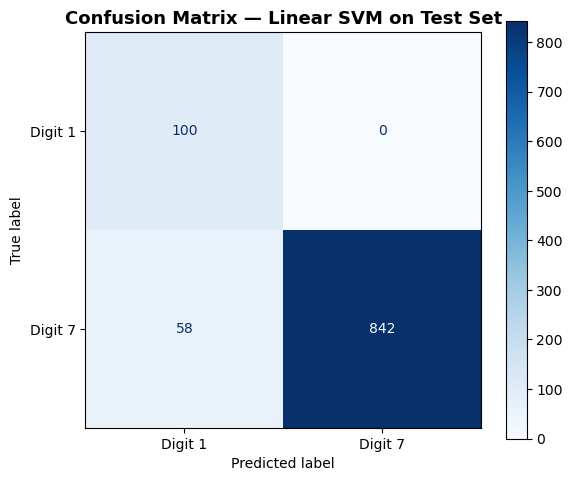

plot saved


In [13]:
# confusion matrix shows exactly where model made mistakes
# rows are actual labels, columns are predicted labels
cm = confusion_matrix(y_test, y_pred, labels=[1, 7])

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Digit 1', 'Digit 7'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Confusion Matrix — Linear SVM on Test Set', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('viz5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

## Step 2.5 (Results Summary)

Model got 94.20% accuracy which is pretty good for only 100 training samples.

Precision is 1.0 meaning every time model said digit 7 it was actually digit 7, no false alarms at all. It missed 58 out of 900 sevens which give recall of 0.9356. F1 of 0.9667 and ROC AUC of 0.9876 both look strong.

Confusion matrix show model got every single digit 1 correct, all errors were digit 7s predicted as 1. Some 7s without crossbar probably look too similar to 1 from pixel side.

Overall Linear SVM did really well here, linear boundary was enough to separate these two digits even with tiny training set.

# Task 3: Comparison of Two Classifiers & Hyperparameter Tuning

In this task we bring in a second classifier, tune hyperparameters for both models using cross validation on training data only, then compare them properly.

## Step 3.1 (Second Model Choice)

Our first model was Linear SVM which is a parametric linear model. For the second model we going with **K-Nearest Neighbours (KNN)** which is completely different type — it is non-parametric and instance based, meaning it dont learn a boundary during training, it just memorise all training samples and at prediction time it find the nearest neighbours. We tune this properly in the next steps.

## Step 3.2 (Cross Validation Setup)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# we use 5 fold stratified cross validation on training data only
# stratified means each fold keep same class ratio as original data
# this is important because we only got 100 samples so we need to be careful
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross validation setup done")
print(f"Number of folds : {cv.n_splits}")
print(f"Total training samples : {len(X_train_flat)}")
print(f"Approx samples per fold : {len(X_train_flat) // cv.n_splits}")

Cross validation setup done
Number of folds : 5
Total training samples : 100
Approx samples per fold : 20


## Step 3.3 (Hyperparameter Tuning for Linear SVM (Parameter: C))

In [16]:
# testing C across wide range for linear SVM
# C controls how strict the model is about misclassification
# small C = more relaxed, large C = tries harder to get every sample right
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

svm_cv_scores = []

for c in C_values:
    model = SVC(kernel='linear', C=c, probability=True, random_state=42)
    # cross val score returns f1 score for each fold, we take mean
    scores = cross_val_score(model, X_train_flat, y_train, 
                             cv=cv, scoring='f1_macro')
    svm_cv_scores.append(scores.mean())
    print(f"C = {c:<8} | CV F1 = {scores.mean():.4f}")

# find best C value
best_C_idx = np.argmax(svm_cv_scores)
best_C     = C_values[best_C_idx]
print(f"\nBest C value : {best_C}")
print(f"Best CV F1   : {svm_cv_scores[best_C_idx]:.4f}")

C = 0.0001   | CV F1 = 0.9189
C = 0.001    | CV F1 = 0.9189
C = 0.01     | CV F1 = 0.9799
C = 0.1      | CV F1 = 0.9900
C = 1        | CV F1 = 0.9900
C = 10       | CV F1 = 0.9900
C = 100      | CV F1 = 0.9900
C = 1000     | CV F1 = 0.9900

Best C value : 0.1
Best CV F1   : 0.9900


## Step 3.4 (SVM Hyperparameter Tuning Plot)

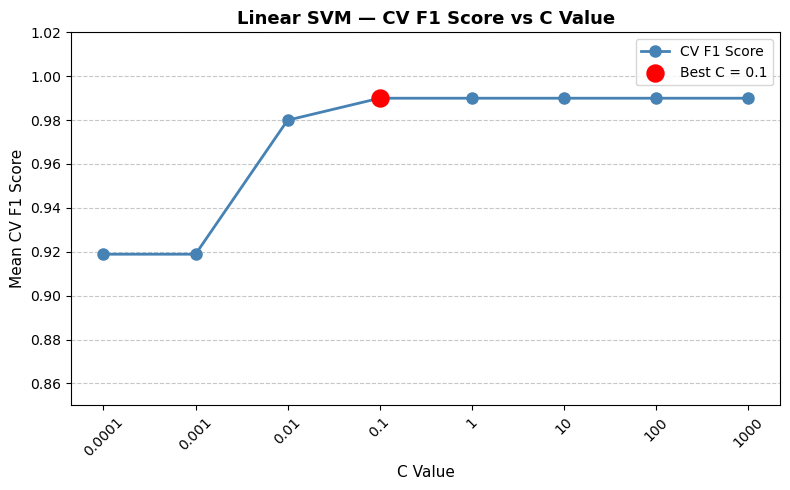

plot saved


In [17]:
# plot how CV F1 score changes as C value changes
# this help us see where model performance stabilise
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(len(C_values)), svm_cv_scores, 
        marker='o', linewidth=2, markersize=8, color='steelblue', label='CV F1 Score')

# highlight the best C value with red dot
ax.scatter(best_C_idx, svm_cv_scores[best_C_idx], 
           color='red', s=150, zorder=5, label=f'Best C = {best_C}')

ax.set_xticks(range(len(C_values)))
ax.set_xticklabels([str(c) for c in C_values], rotation=45)
ax.set_xlabel('C Value', fontsize=11)
ax.set_ylabel('Mean CV F1 Score', fontsize=11)
ax.set_title('Linear SVM — CV F1 Score vs C Value', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_ylim(0.85, 1.02)

plt.tight_layout()
plt.savefig('viz6_svm_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

## Step 3.5 (Hyperparameter Tuning for KNN (Parameters: n_neighbors and metric))

In [18]:
# tuning two parameters for KNN
# n_neighbors = how many nearest neighbours to look at when making prediction
# metric = how we measure distance between samples
k_values      = [1, 3, 5, 7, 9, 11, 15, 20, 25, 30]
distance_metrics = ['euclidean', 'manhattan']

knn_cv_scores = {}

for metric in distance_metrics:
    knn_cv_scores[metric] = []
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        scores = cross_val_score(model, X_train_flat, y_train,
                                 cv=cv, scoring='f1_macro')
        knn_cv_scores[metric].append(scores.mean())
        print(f"metric = {metric:<12} | k = {k:<4} | CV F1 = {scores.mean():.4f}")

# find best combination of k and metric
best_score  = 0
best_k      = None
best_metric = None

for metric in distance_metrics:
    for i, k in enumerate(k_values):
        if knn_cv_scores[metric][i] > best_score:
            best_score  = knn_cv_scores[metric][i]
            best_k      = k
            best_metric = metric

print(f"\nBest k      : {best_k}")
print(f"Best metric : {best_metric}")
print(f"Best CV F1  : {best_score:.4f}")

metric = euclidean    | k = 1    | CV F1 = 0.9799
metric = euclidean    | k = 3    | CV F1 = 0.9597
metric = euclidean    | k = 5    | CV F1 = 0.9699
metric = euclidean    | k = 7    | CV F1 = 0.9597
metric = euclidean    | k = 9    | CV F1 = 0.9493
metric = euclidean    | k = 11   | CV F1 = 0.9497
metric = euclidean    | k = 15   | CV F1 = 0.9291
metric = euclidean    | k = 20   | CV F1 = 0.9181
metric = euclidean    | k = 25   | CV F1 = 0.9079
metric = euclidean    | k = 30   | CV F1 = 0.8979
metric = manhattan    | k = 1    | CV F1 = 0.9699
metric = manhattan    | k = 3    | CV F1 = 0.9597
metric = manhattan    | k = 5    | CV F1 = 0.9597
metric = manhattan    | k = 7    | CV F1 = 0.9493
metric = manhattan    | k = 9    | CV F1 = 0.9392
metric = manhattan    | k = 11   | CV F1 = 0.9392
metric = manhattan    | k = 15   | CV F1 = 0.9181
metric = manhattan    | k = 20   | CV F1 = 0.8979
metric = manhattan    | k = 25   | CV F1 = 0.8979
metric = manhattan    | k = 30   | CV F1 = 0.8757


## Step 3.6 (KNN Hyperparameter Tuning Plot)

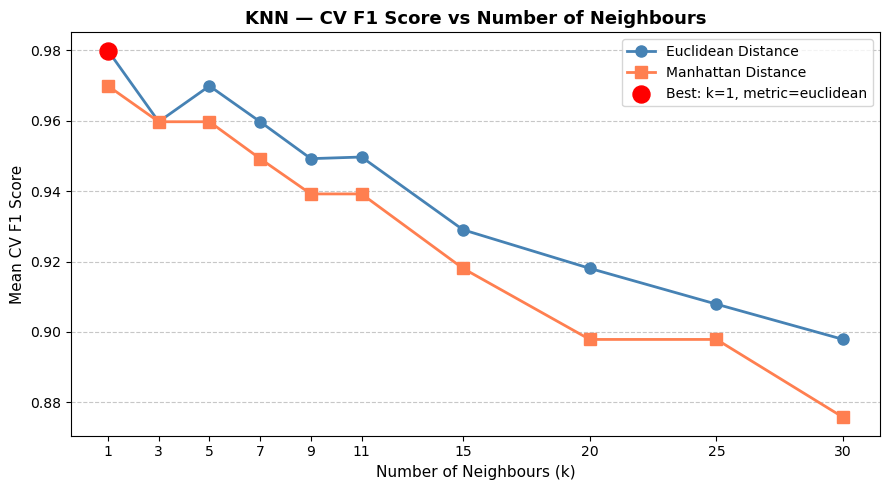

plot saved


In [19]:
# plot CV F1 score for both distance metrics across all k values
# this show us how performance change as k increases for each metric
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(k_values, knn_cv_scores['euclidean'], 
        marker='o', linewidth=2, markersize=8, 
        color='steelblue', label='Euclidean Distance')

ax.plot(k_values, knn_cv_scores['manhattan'], 
        marker='s', linewidth=2, markersize=8, 
        color='coral', label='Manhattan Distance')

# highlight the best combination
best_k_idx = k_values.index(best_k)
ax.scatter(best_k, knn_cv_scores[best_metric][best_k_idx], 
           color='red', s=150, zorder=5, 
           label=f'Best: k={best_k}, metric={best_metric}')

ax.set_xlabel('Number of Neighbours (k)', fontsize=11)
ax.set_ylabel('Mean CV F1 Score', fontsize=11)
ax.set_title('KNN — CV F1 Score vs Number of Neighbours', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_xticks(k_values)

plt.tight_layout()
plt.savefig('viz7_knn_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

## Step 3.7 (Train Final Models with Best Hyperparameters)

In [20]:
# train final SVM with best C found from cross validation
final_svm = SVC(kernel='linear', C=best_C, probability=True, random_state=42)
final_svm.fit(X_train_flat, y_train)

# train final KNN with best k and best metric found from cross validation
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
final_knn.fit(X_train_flat, y_train)

print("Both final models trained successfully")
print(f"Final SVM : linear kernel, C = {best_C}")
print(f"Final KNN : k = {best_k}, metric = {best_metric}")

Both final models trained successfully
Final SVM : linear kernel, C = 0.1
Final KNN : k = 1, metric = euclidean


## Step 3.8 (Final Model Comparison on Test Set)

In [22]:
# get predictions for both models on test set
svm_pred = final_svm.predict(X_test_flat)
knn_pred = final_knn.predict(X_test_flat)

# get probability scores for ROC AUC
svm_prob = final_svm.predict_proba(X_test_flat)[:, 1]
knn_prob = final_knn.predict_proba(X_test_flat)[:, 1]

# calculate all metrics for both models
results = {
    'Linear SVM': {
        'Accuracy'  : accuracy_score(y_test, svm_pred),
        'F1 Score'  : f1_score(y_test, svm_pred, pos_label=7),
        'Precision' : precision_score(y_test, svm_pred, pos_label=7),
        'Recall'    : recall_score(y_test, svm_pred, pos_label=7),
        'ROC AUC'   : roc_auc_score(y_test, svm_prob)
    },
    'KNN': {
        'Accuracy'  : accuracy_score(y_test, knn_pred),
        'F1 Score'  : f1_score(y_test, knn_pred, pos_label=7),
        'Precision' : precision_score(y_test, knn_pred, pos_label=7),
        'Recall'    : recall_score(y_test, knn_pred, pos_label=7),
        'ROC AUC'   : roc_auc_score(y_test, knn_prob)
    }
}

# print comparison table
print(f"{'Metric':<12} {'Linear SVM':>12} {'KNN':>12}")
for metric in ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC']:
    svm_val = results['Linear SVM'][metric]
    knn_val = results['KNN'][metric]
    print(f"{metric:<12} {svm_val:>12.4f} {knn_val:>12.4f}")

Metric         Linear SVM          KNN
Accuracy           0.9420       0.9430
F1 Score           0.9667       0.9673
Precision          1.0000       0.9988
Recall             0.9356       0.9378
ROC AUC            0.9876       0.9639


## Step 3.9 (Model Comparison Visualisation)

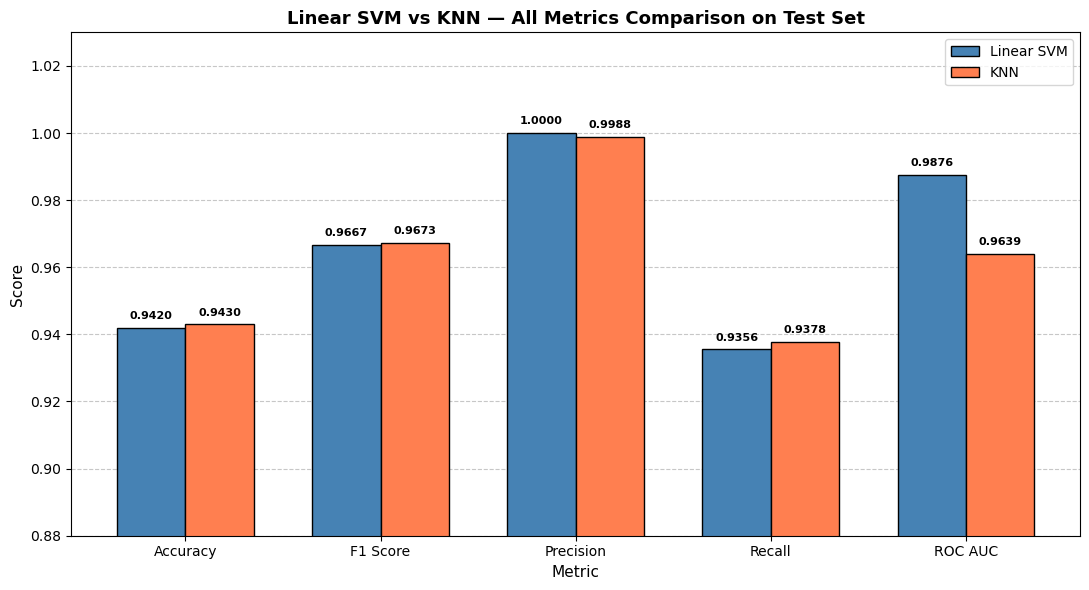

plot saved


In [23]:
# bar chart comparing both models across all metrics side by side
metrics     = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC AUC']
svm_scores  = [results['Linear SVM'][m] for m in metrics]
knn_scores  = [results['KNN'][m] for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, svm_scores, width, 
               label='Linear SVM', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, knn_scores, width, 
               label='KNN', color='coral', edgecolor='black')

# put score value on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', 
            ha='center', va='bottom', fontsize=8, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', 
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Linear SVM vs KNN — All Metrics Comparison on Test Set', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.88, 1.03)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

## Step 3.10 (Confusion Matrices for Both Models)

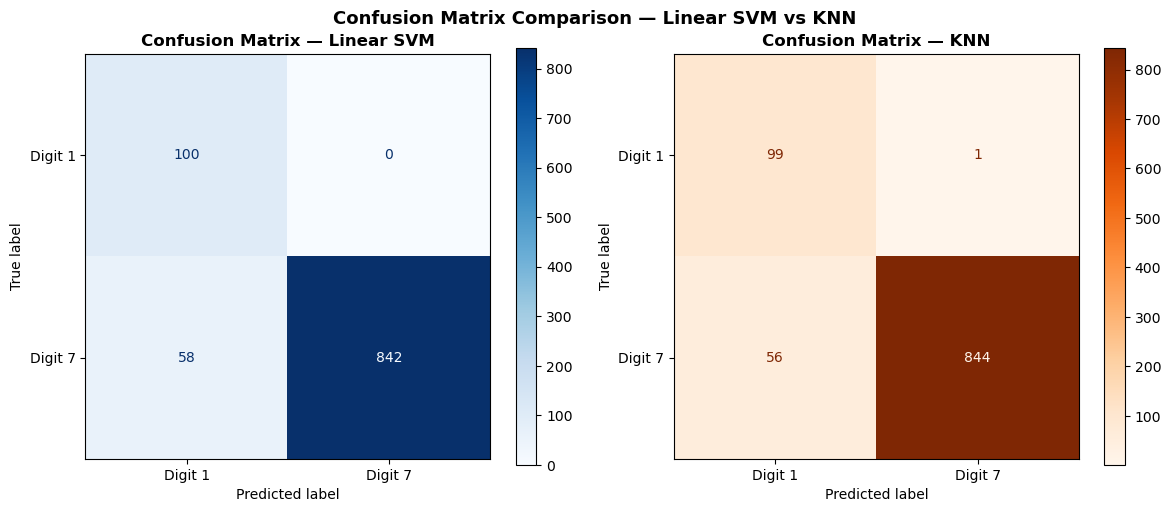

plot saved


In [24]:
# confusion matrices for both models side by side
# easy to see exactly where each model makes mistakes
cm_svm = confusion_matrix(y_test, svm_pred, labels=[1, 7])
cm_knn = confusion_matrix(y_test, knn_pred, labels=[1, 7])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SVM confusion matrix
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_svm, 
                                display_labels=['Digit 1', 'Digit 7'])
disp1.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Confusion Matrix — Linear SVM', 
                   fontsize=12, fontweight='bold')

# KNN confusion matrix
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_knn, 
                                display_labels=['Digit 1', 'Digit 7'])
disp2.plot(ax=axes[1], colorbar=True, cmap='Oranges')
axes[1].set_title('Confusion Matrix — KNN', 
                   fontsize=12, fontweight='bold')

fig.suptitle('Confusion Matrix Comparison — Linear SVM vs KNN', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('viz9_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

## Step 3.11 (Task 3 Summary)

Best SVM got C=0.1 with CV F1 of 0.9900 and best KNN got k=1 euclidean with CV F1 of 0.9799.

On test set both models did really well and scores are very close. KNN edged SVM slightly on accuracy, F1 and recall but SVM won by big margin on ROC AUC (0.9876 vs 0.9639) and got perfect precision of 1.0.

SVM got all 100 digit 1s right with zero mistakes. KNN missed 1 digit 1 but got 2 fewer 7s wrong. Very close overall.

SVM has much better ROC AUC because it produce smoother probability scores across all thresholds. KNN with k=1 is too sensitive to individual training samples so its probability estimates are less reliable even though raw predictions are slightly better.

# Task 4: Clustering Analysis of the Test Set

In this task we take only the digit 7 samples from test set, cluster them first into 100 clusters, then find the optimal number of clusters and visualise each one properly.

## Step 4.1 (Extract Digit 7 Samples from Test Set)

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# pull out only digit 7 samples from test set
# test set was never touched during training or tuning so its clean
X_test_7 = X_test_flat[y_test == 7]

print("Digit 7 samples extracted from test set")
print(f"Total digit 7 samples : {X_test_7.shape[0]}")
print(f"Each sample has       : {X_test_7.shape[1]} features (784 pixels)")

Digit 7 samples extracted from test set
Total digit 7 samples : 900
Each sample has       : 784 features (784 pixels)


## Step 4.2 (K-Means Clustering with k=100)

In [27]:
# first we cluster digit 7 samples into 100 clusters as required
# n_init=10 mean kmeans run 10 times with different starting points and pick best result
# random_state=42 make sure we get same result every time we run
kmeans_100 = KMeans(n_clusters=100, n_init=10, random_state=42)
kmeans_100.fit(X_test_7)

# inertia is sum of squared distances from each sample to its cluster centre
# lower inertia mean samples are closer to their cluster centre which is better
print("K-Means with k=100 done")
print(f"Number of clusters : {kmeans_100.n_clusters}")
print(f"Inertia            : {kmeans_100.inertia_:.2f}")

# check how many samples ended up in each cluster
unique, counts = np.unique(kmeans_100.labels_, return_counts=True)
print(f"\nSmallest cluster size : {counts.min()} samples")
print(f"Largest cluster size  : {counts.max()} samples")
print(f"Average cluster size  : {counts.mean():.1f} samples")

K-Means with k=100 done
Number of clusters : 100
Inertia            : 12519.34

Smallest cluster size : 1 samples
Largest cluster size  : 23 samples
Average cluster size  : 9.0 samples


## Step 4.3 (Finding Optimal Number of Clusters)

In [28]:
# we test k values from 2 to 30 to find optimal number of clusters
# two methods used together: elbow method and silhouette score
# elbow method look at inertia, silhouette score look at how well separated clusters are
k_range      = range(2, 31)
inertia_vals = []
sil_vals     = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_test_7)
    inertia_vals.append(km.inertia_)
    # silhouette score goes from -1 to 1, higher is better
    sil_score = silhouette_score(X_test_7, km.labels_)
    sil_vals.append(sil_score)
    print(f"k = {k:<3} | Inertia = {km.inertia_:.2f} | Silhouette = {sil_score:.4f}")

# best k is where silhouette score is highest
best_k_idx      = np.argmax(sil_vals)
optimal_k       = list(k_range)[best_k_idx]
best_sil_score  = sil_vals[best_k_idx]

print(f"\nOptimal k : {optimal_k}")
print(f"Best silhouette score : {best_sil_score:.4f}")

k = 2   | Inertia = 28571.23 | Silhouette = 0.1217
k = 3   | Inertia = 26262.63 | Silhouette = 0.1087
k = 4   | Inertia = 24857.35 | Silhouette = 0.1009
k = 5   | Inertia = 23929.27 | Silhouette = 0.0814
k = 6   | Inertia = 23192.37 | Silhouette = 0.0797
k = 7   | Inertia = 22530.84 | Silhouette = 0.0811
k = 8   | Inertia = 21927.60 | Silhouette = 0.0725
k = 9   | Inertia = 21473.82 | Silhouette = 0.0727
k = 10  | Inertia = 21145.70 | Silhouette = 0.0700
k = 11  | Inertia = 20736.15 | Silhouette = 0.0636
k = 12  | Inertia = 20409.92 | Silhouette = 0.0710
k = 13  | Inertia = 20152.31 | Silhouette = 0.0683
k = 14  | Inertia = 19833.06 | Silhouette = 0.0703
k = 15  | Inertia = 19648.43 | Silhouette = 0.0655
k = 16  | Inertia = 19329.16 | Silhouette = 0.0632
k = 17  | Inertia = 19098.75 | Silhouette = 0.0687
k = 18  | Inertia = 18911.96 | Silhouette = 0.0690
k = 19  | Inertia = 18859.50 | Silhouette = 0.0526
k = 20  | Inertia = 18590.04 | Silhouette = 0.0670
k = 21  | Inertia = 18383.01 | 

## Step 4.4 (Elbow Method and Silhouette Score Plots)

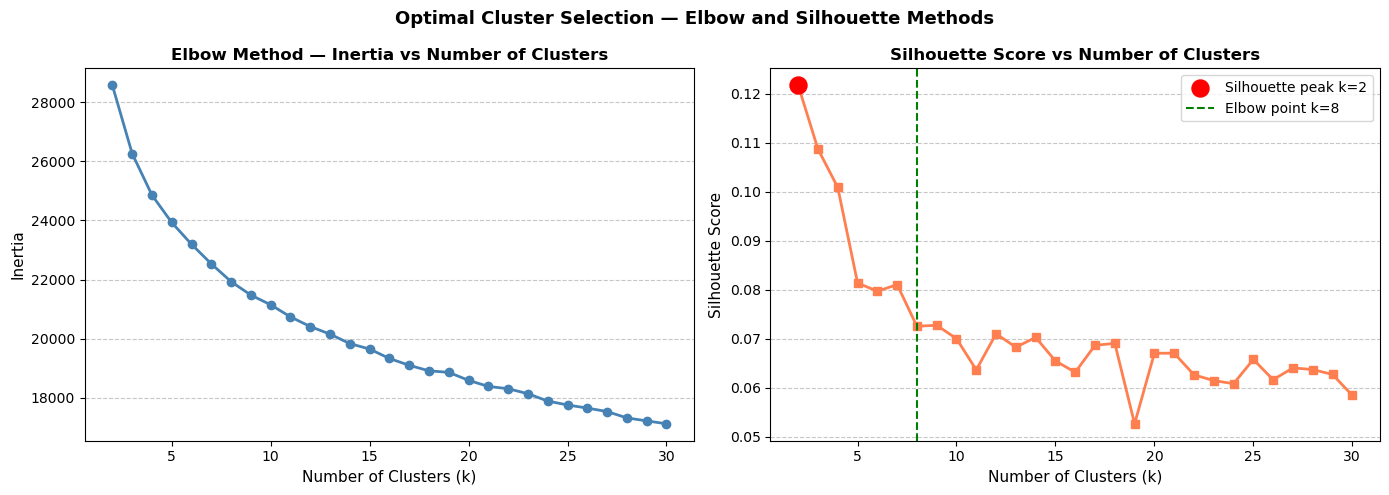

plot saved


In [30]:
# elbow method: look for where inertia starts dropping slower (the bend)
# silhouette: higher score mean clusters are more separated and compact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# elbow plot
axes[0].plot(list(k_range), inertia_vals, 
             marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method — Inertia vs Number of Clusters', 
                   fontsize=12, fontweight='bold')
axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

# silhouette plot
axes[1].plot(list(k_range), sil_vals, 
             marker='s', linewidth=2, markersize=6, color='coral')

# mark k=2 as silhouette peak
axes[1].scatter(optimal_k, best_sil_score, 
                color='red', s=150, zorder=5, 
                label=f'Silhouette peak k={optimal_k}')

# also mark k=8 as elbow point for discussion
axes[1].axvline(x=8, color='green', linestyle='--', 
                linewidth=1.5, label='Elbow point k=8')

axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score vs Number of Clusters', 
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

fig.suptitle('Optimal Cluster Selection — Elbow and Silhouette Methods', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('viz10_optimal_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

## Step 4.5 (Final K-Means with Optimal k=8)

In [31]:
# based on elbow and silhouette analysis we pick k=8 as optimal
# elbow plot shows clear bend at k=8 where inertia stops dropping fast
# silhouette score is still reasonable at k=8 before it completely flattens out
# k=2 silhouette peak is too simple to capture meaningful variation in digit 7 writing styles
optimal_k = 8

kmeans_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
kmeans_final.fit(X_test_7)

# get cluster labels and cluster centres for each sample
labels   = kmeans_final.labels_
centres  = kmeans_final.cluster_centers_

print(f"Final K-Means done with k={optimal_k}")
print(f"Inertia : {kmeans_final.inertia_:.2f}")
print(f"Silhouette score : {silhouette_score(X_test_7, labels):.4f}")

# show how many samples are in each cluster
print("\nSamples per cluster")
for i in range(optimal_k):
    count = np.sum(labels == i)
    print(f"Cluster {i+1} : {count} samples")

Final K-Means done with k=8
Inertia : 21927.60
Silhouette score : 0.0725

Samples per cluster
Cluster 1 : 90 samples
Cluster 2 : 130 samples
Cluster 3 : 106 samples
Cluster 4 : 119 samples
Cluster 5 : 90 samples
Cluster 6 : 156 samples
Cluster 7 : 93 samples
Cluster 8 : 116 samples


## Step 4.6 (Cluster Visualisation,Centre and Sample Images per Cluster)

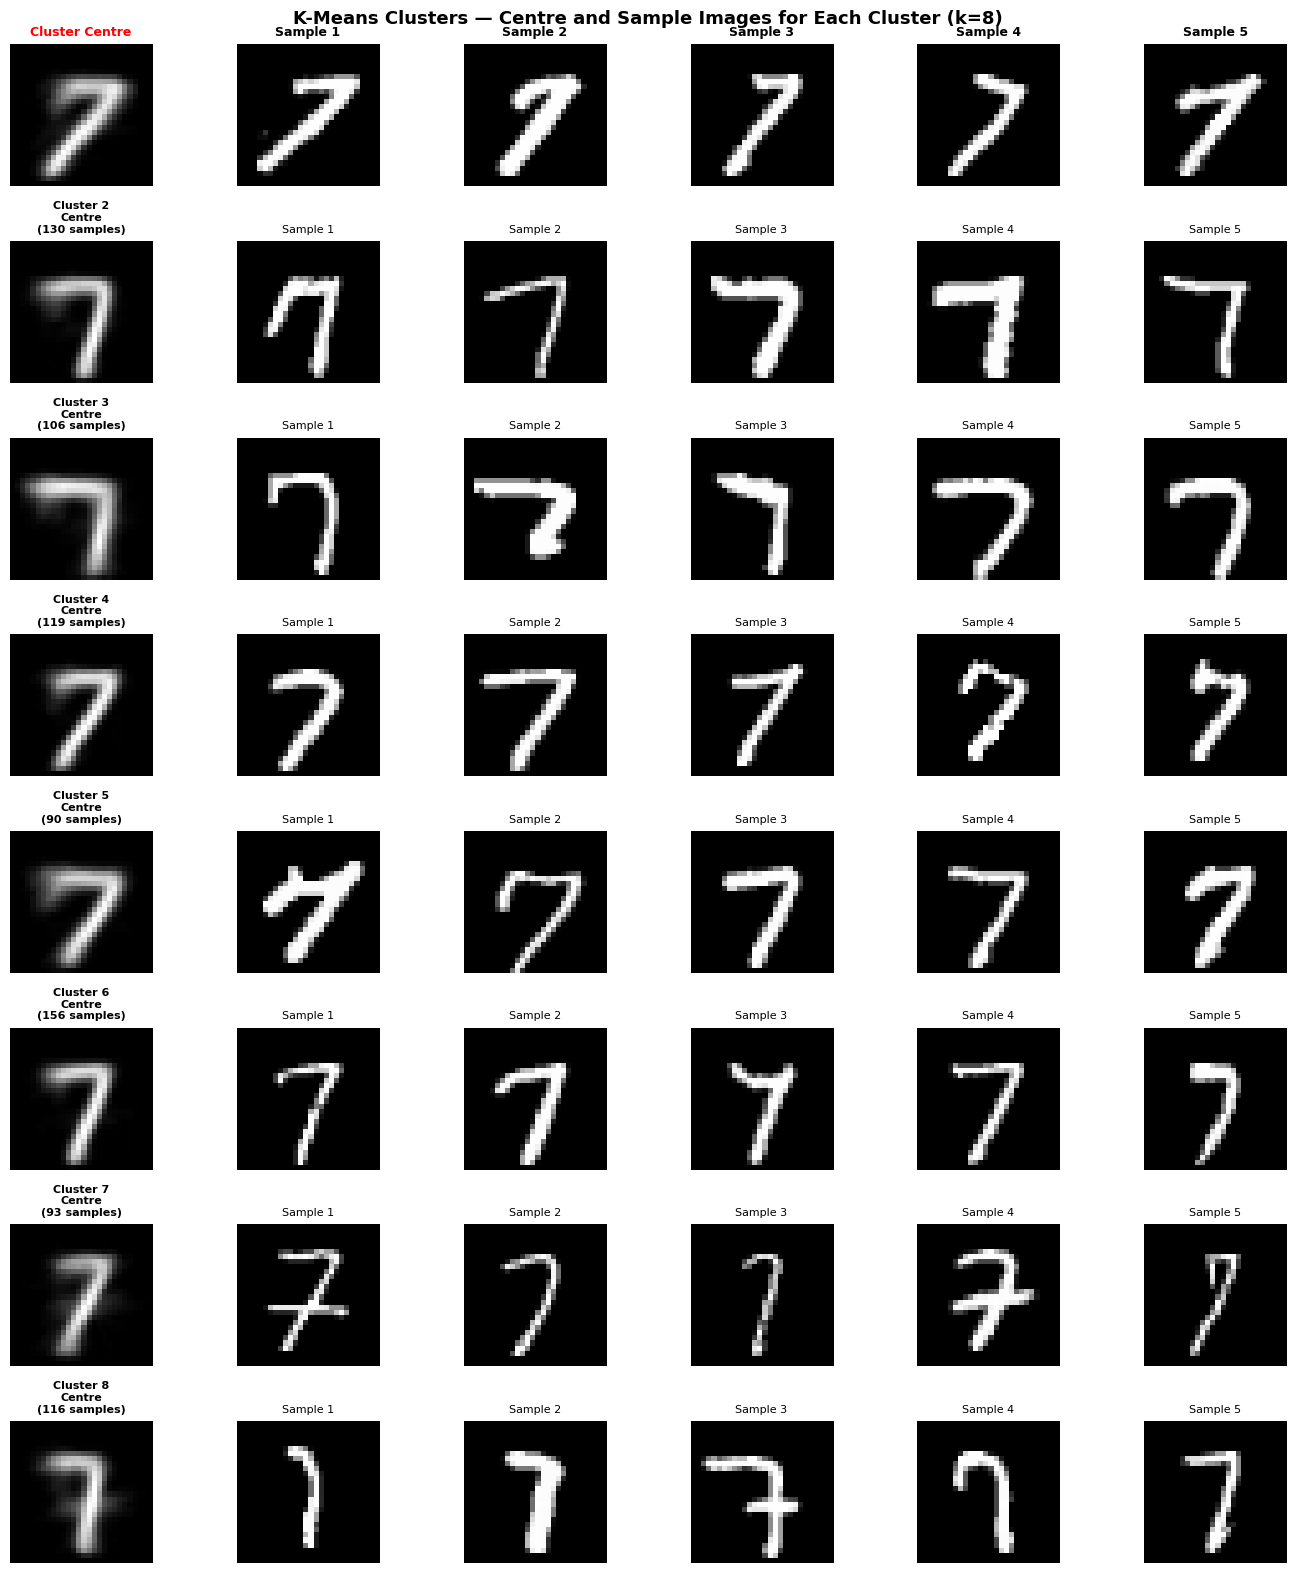

plot saved


In [32]:
# for each cluster we show:
# 1. The cluster centre (average of all samples in that cluster)
# 2. five real sample images from that cluster
# this give us full picture of what each cluster looks like
fig, axes = plt.subplots(optimal_k, 6, figsize=(14, optimal_k * 2))

for cluster_idx in range(optimal_k):
    
    # get all samples that belong to this cluster
    cluster_samples = X_test_7[labels == cluster_idx]
    cluster_size    = len(cluster_samples)
    
    # cluster centre is the mean of all samples in this cluster
    # reshape from 784 flat back to 28x28 image for display
    centre_img = centres[cluster_idx].reshape(28, 28)
    
    # show cluster centre in first column
    axes[cluster_idx, 0].imshow(centre_img, cmap='gray')
    axes[cluster_idx, 0].set_title(f'Cluster {cluster_idx+1}\nCentre\n({cluster_size} samples)', 
                                    fontsize=8, fontweight='bold')
    axes[cluster_idx, 0].axis('off')
    
    # show 5 random sample images from this cluster in next 5 columns
    sample_indices = np.random.choice(cluster_size, min(5, cluster_size), replace=False)
    for col, sample_idx in enumerate(sample_indices):
        sample_img = cluster_samples[sample_idx].reshape(28, 28)
        axes[cluster_idx, col+1].imshow(sample_img, cmap='gray')
        axes[cluster_idx, col+1].set_title(f'Sample {col+1}', fontsize=8)
        axes[cluster_idx, col+1].axis('off')

# label the columns at top
axes[0, 0].set_title('Cluster Centre', fontsize=9, fontweight='bold', color='red')
for col in range(1, 6):
    axes[0, col].set_title(f'Sample {col}', fontsize=9, fontweight='bold')

fig.suptitle('K-Means Clusters — Centre and Sample Images for Each Cluster (k=8)', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('viz11_cluster_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")

## Step 4.7 (Per Cluster Analysis)

**Cluster 1 (90 samples):** Classic 7 with thick confident strokes, clear horizontal top and clean diagonal going down.

**Cluster 2 (130 samples):** Smaller 7 leaning left, shorter top stroke and diagonal is more curved than straight.

**Cluster 3 (106 samples):** Flat top stroke with sharp 90 degree corner, diagonal goes more straight down, square looking 7.

**Cluster 4 (119 samples):** Tall narrow 7 with thin steep strokes, some samples got small tick at bottom of diagonal.

**Cluster 5 (90 samples):** European style 7 with crossbar through the middle, steep diagonal and thinner strokes.

**Cluster 6 (156 samples):** Big bold 7 spread across most of the image, long top stroke and wide diagonal, most common style.

**Cluster 7 (93 samples):** Curved diagonal almost like backwards C at bottom, top stroke length varies a lot between samples.

**Cluster 8 (116 samples):** Small 7 sitting low in image, thin strokes, some look quickly written with barely visible top stroke.

## Step 4.8 (Task 4 Summary)

Took 900 digit 7 samples and clustered into 100 first then used elbow and silhouette to find k=8 as optimal.

Elbow bend around k=8 and silhouette flattened after that so k=8 made most sense. Clusters ranged from 90 to 156 samples each.

8 clusters show real differences in writing styles-stroke thickness, angle, crossbar, size and position all vary across clusters.